/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


Train rows: 1460 | Features: 79
Numeric cols: 36 | Categorical cols: 43

=== CV Benchmark (lower RMSE is better) ===
Linear Regression  | RMSE: 0.15274 (± 0.04702)
Ridge Regression   | RMSE: 0.14679 (± 0.03935)
Lasso Regression   | RMSE: 0.14108 (± 0.04298)
Random Forest      | RMSE: 0.14473 (± 0.01909)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM           | RMSE: 0.13390 (± 0.01808)

✅ Best Model: LightGBM | CV RMSE: 0.13390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3372
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 187
[LightGBM] [Info] Start training from score 12.024057

✅ submission.csv created successfully!

--- SHAP Explainability ---


100%|===================| 997/1000 [04:28<00:00]       

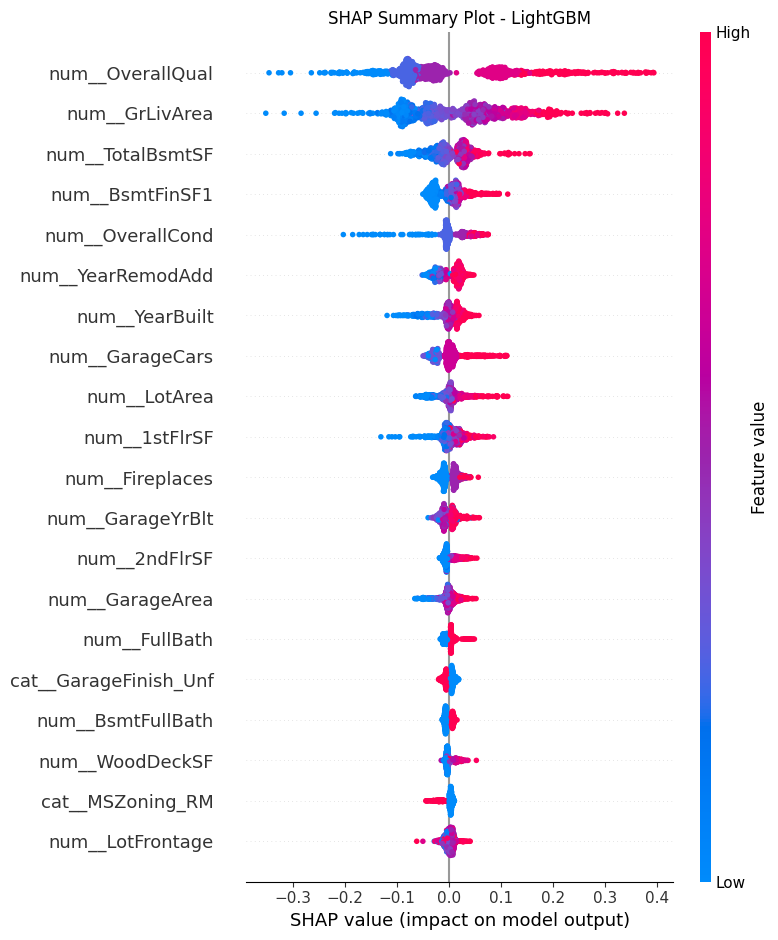

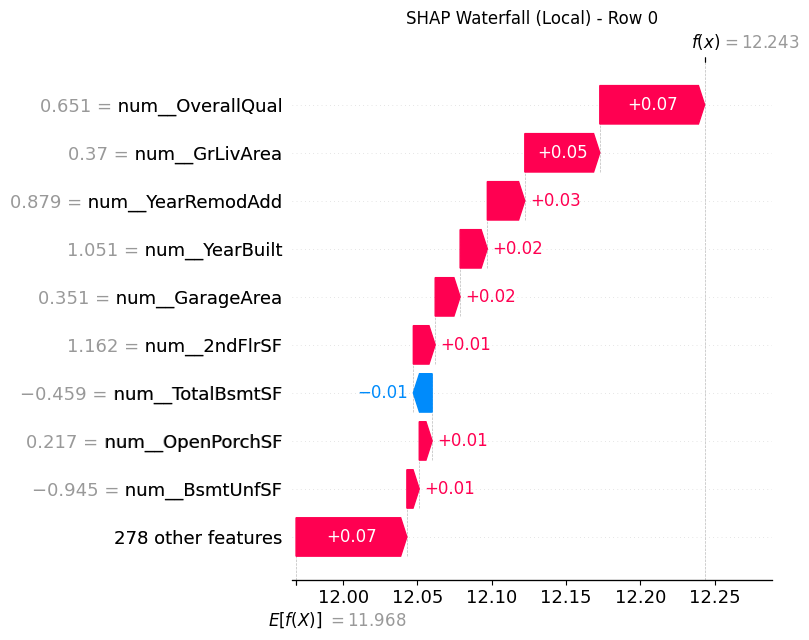

In [1]:


import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"sklearn\.utils\.validation",
    message=r"X does not have valid feature names, but LGBMRegressor was fitted with feature names"
)

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

import shap
import matplotlib.pyplot as plt


# ----------------------------
# 1) Load Data
# ----------------------------
TRAIN_PATH = "/kaggle/input/house-prices-advanced-regression-techniques/train.csv"
TEST_PATH  = "/kaggle/input/house-prices-advanced-regression-techniques/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

test_ids = test_df["Id"].copy()


# ----------------------------
# 2) Target + Features
# ----------------------------
y = np.log1p(train_df["SalePrice"])
X = train_df.drop(columns=["SalePrice"]).copy()
X_test = test_df.copy()

X = X.drop(columns=["Id"])
X_test = X_test.drop(columns=["Id"])


# ----------------------------
# 3) Column Types
# ----------------------------
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Train rows:", X.shape[0], "| Features:", X.shape[1])
print("Numeric cols:", len(num_cols), "| Categorical cols:", len(cat_cols))


# ----------------------------
# 4) Preprocessing
# ----------------------------
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ],
    remainder="drop"
)


# ----------------------------
# 5) Models
# ----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0, solver="lsqr", random_state=42),
    "Lasso Regression": Lasso(alpha=0.0005, random_state=42, max_iter=20000),
    "Random Forest": RandomForestRegressor(n_estimators=600, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
}


# ----------------------------
# 6) CV Function
# ----------------------------
def get_cv_rmse(model, X, y):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipe, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        error_score="raise"
    )
    return -scores.mean(), scores.std()


# ----------------------------
# 7) Benchmark
# ----------------------------
best_name, best_model, best_rmse = None, None, 1e9
print("\n=== CV Benchmark (lower RMSE is better) ===")

for name, model in models.items():
    mean_rmse, std_rmse = get_cv_rmse(model, X, y)
    print(f"{name:18s} | RMSE: {mean_rmse:.5f} (± {std_rmse:.5f})")

    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_name = name
        best_model = model

print(f"\n✅ Best Model: {best_name} | CV RMSE: {best_rmse:.5f}")


# ----------------------------
# 8) Fit Best Model
# ----------------------------
best_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_model)
])

best_pipeline.fit(X, y)


# ----------------------------
# 9) Predict + Submission
# ----------------------------
test_pred_log = best_pipeline.predict(X_test)
test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_pred})
submission.to_csv("submission.csv", index=False)

print("\n✅ submission.csv created successfully!")


# ----------------------------
# 10) SHAP Explainability
# ----------------------------
if best_name in ["Random Forest", "LightGBM"]:
    print("\n--- SHAP Explainability ---")

    model_fitted = best_pipeline.named_steps["model"]
    preproc_fitted = best_pipeline.named_steps["preprocess"]

    X_trans = preproc_fitted.transform(X)
    X_dense = X_trans.toarray() if hasattr(X_trans, "toarray") else np.asarray(X_trans)

    try:
        feature_names = preproc_fitted.get_feature_names_out()
        feature_names = [str(f) for f in feature_names]
    except Exception:
        feature_names = [f"f_{i}" for i in range(X_dense.shape[1])]

    X_shap_df = pd.DataFrame(X_dense, columns=feature_names)

    background = X_shap_df.sample(n=min(300, len(X_shap_df)), random_state=42)
    explain_data = X_shap_df.iloc[:min(1000, len(X_shap_df))]

    explainer = shap.Explainer(model_fitted, background)
    shap_exp = explainer(explain_data)

    shap.summary_plot(shap_exp.values, explain_data, show=False)
    plt.title(f"SHAP Summary Plot - {best_name}")
    plt.tight_layout()
    plt.show()

    idx = 0
    shap.plots.waterfall(shap_exp[idx], show=False)
    plt.title(f"SHAP Waterfall (Local) - Row {idx}")
    plt.tight_layout()
    plt.show()
else:
    print("\nSHAP is most effective for RandomForest/LightGBM. Current best model is:", best_name)
